In [1]:
# Preliminaries -----------------------------------------------------------
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, haven)

Loading required package: pacman



## Problem 1

Rows: 161060 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


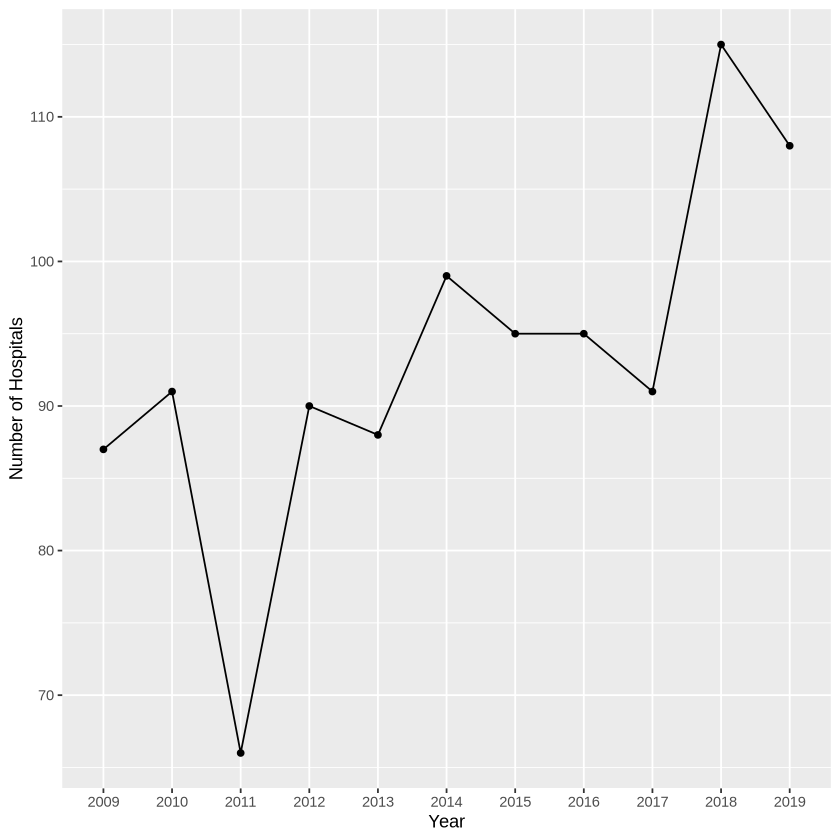

In [2]:
final.hcris <- read_tsv("../data/output/HCRIS_Data.txt")

final.hcris %>% 
  group_by(source, year) %>% 
  filter((source == "total for year")|(source == "weighted_average"))%>%
  group_by(year) %>% 
  summarize("counts" = n()) %>% 
  filter(year >= 2009, year <= 2019) %>%
  ggplot(aes(x = as.factor(year), y = counts)) +
  geom_line(group=1) +
  geom_point() + 
  labs(
       x = "Year",
       y = "Number of Hospitals")

## Problem 2

In [3]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)

final.hcris %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  group_by(year) %>%
  summarise(unique_hospitals = n_distinct(provider_number)) %>%
  kable(
    col.names = c("Year", "Unique Hospitals"),
    booktabs  = TRUE,
    caption   = "Unique Hospital IDs by Year"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE)


Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows




<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Unique Hospital IDs by Year</caption>
 <thead>
  <tr>
   <th style="text-align:right;font-weight: bold;"> Year </th>
   <th style="text-align:right;font-weight: bold;"> Unique Hospitals </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2009 </td>
   <td style="text-align:right;"> 6100 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2010 </td>
   <td style="text-align:right;"> 6103 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2011 </td>
   <td style="text-align:right;"> 6097 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2012 </td>
   <td style="text-align:right;"> 6140 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2013 </td>
   <td style="text-align:right;"> 6066 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2014 </td>
   <td style="text-

## Problem 3

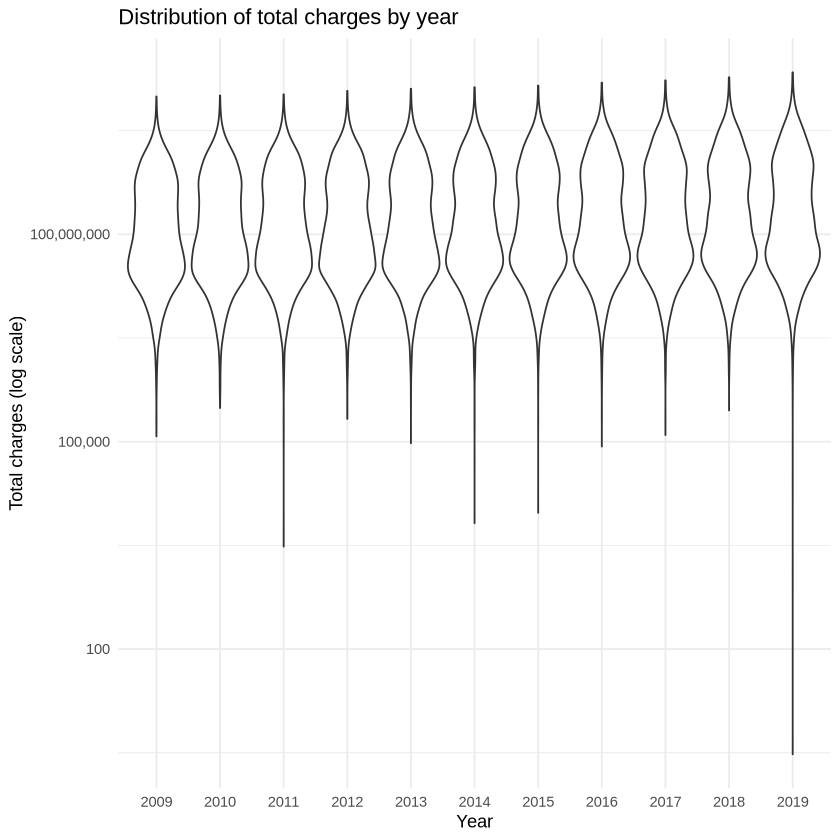

In [4]:
final.hcris %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  filter(tot_charges > 0) %>%
  ggplot(aes(x = factor(year), y = tot_charges)) +
  geom_violin() +
  scale_y_log10(labels = scales::comma) +
  labs(
    title = "Distribution of total charges by year",
    x = "Year",
    y = "Total charges (log scale)"
  ) +
  theme_minimal()

## Problem 4

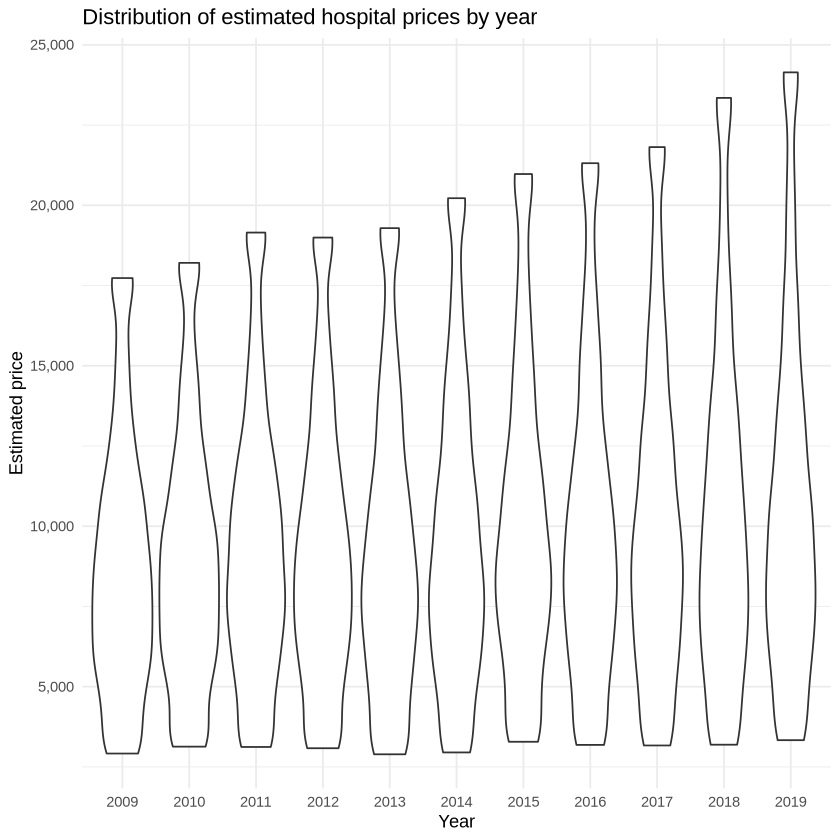

In [5]:
final.hcris %>%
  mutate(
    year = year(fy_end),
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(year >= 2009, year <= 2019) %>%
  filter(price > 0) %>%
  group_by(year) %>%
  mutate(
    p05 = quantile(price, 0.05, na.rm = TRUE),
    p95 = quantile(price, 0.95, na.rm = TRUE),
    price = pmin(pmax(price, p05), p95)
  ) %>%
  ggplot(aes(x = factor(year), y = price)) +
  geom_violin() +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Distribution of estimated hospital prices by year",
    x = "Year",
    y = "Estimated price"
  ) +
  theme_minimal()

## Problem 5

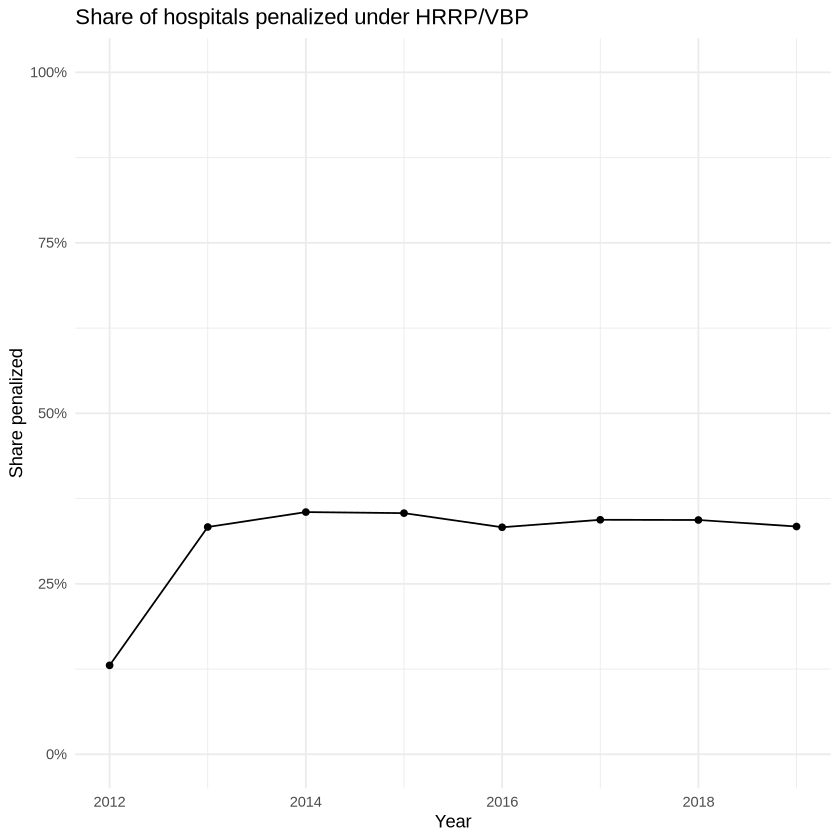

In [6]:
final.hcris %>%
  mutate(
    year = year(fy_end),
    hvbp_payment = ifelse(is.na(hvbp_payment), 0, hvbp_payment),
    hrrp_payment = ifelse(is.na(hrrp_payment), 0, abs(hrrp_payment)),
    penalty = as.numeric((hvbp_payment - hrrp_payment) < 0)
  ) %>%
  filter(year >= 2012, year <= 2019) %>%
  group_by(year) %>%
  summarise(share_penalized = mean(penalty, na.rm = TRUE)) %>%
  
ggplot(aes(x = year, y = share_penalized)) +
  geom_line() +
  geom_point() +
  scale_y_continuous(labels = scales::percent, limits = c(0, 1)) +
  labs(
    title = "Share of hospitals penalized under HRRP/VBP",
    x = "Year",
    y = "Share penalized"
  ) +
  theme_minimal()

## Problem 6

In [7]:
hcris.price <- final.hcris %>%
  mutate(
    year = year(fy_end),
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(price > 0) %>%
  group_by(year) %>%
  mutate(
    p05 = quantile(price, 0.05, na.rm = TRUE),
    p95 = quantile(price, 0.95, na.rm = TRUE),
    price = pmin(pmax(price, p05), p95)
  ) %>%
  ungroup() %>%
  select(provider_number, year, price, beds, mcare_discharges, mcaid_discharges, hrrp_payment, hvbp_payment)

price.wide <- hcris.price %>%
  filter(year %in% c(2011, 2014)) %>%
  select(provider_number, year, price) %>%
  pivot_wider(names_from = year, values_from = price, names_prefix = "price_")

penalty.2012 <- final.hcris %>%
  filter(year == 2012) %>%
  mutate(net_penalty = hvbp_payment - hrrp_payment) %>%
  select(provider_number, net_penalty)

pre.2012 <- final.hcris %>%
  filter(year >= 2009, year <= 2011) %>%
  group_by(provider_number) %>%
  summarise(
    avg_mcare = mean(mcare_discharges, na.rm = TRUE),
    avg_beds = mean(beds, na.rm = TRUE),
    avg_mcaid = mean(mcaid_discharges, na.rm = TRUE)
  )

hcris.final <- price.wide %>%
  filter(!is.na(price_2011) & !is.na(price_2014)) %>%
  left_join(penalty.2012, by = "provider_number") %>%
  left_join(pre.2012, by = "provider_number") %>%
  mutate(price_change = price_2014 - price_2011) 
  #filter(!is.na(price_change), !is.na(net_penalty), !is.na(avg_mcare))

fmt_p <- function(p) ifelse(is.na(p), NA, sprintf("%.3f", p))

ols1 <- lm(price_change ~ net_penalty, data = hcris.final)
ols2 <- lm(price_change ~ net_penalty + avg_beds, data = hcris.final)
ols3 <- lm(price_change ~ net_penalty + avg_beds + avg_mcaid, data = hcris.final)

In [8]:
data.frame(
  Statistic = c(
    "Intercept", "p-value",
    "Net Penalty", "p-value",
    "Avg Beds (Pre-2012)", "p-value",
    "Avg Medicaid Discharges (Pre-2012)", "p-value",
    "# Obs", "R2"
  ),
  `OLS 1` = c(
    round(coef(ols1)["(Intercept)"], 3),
    fmt_p(coef(summary(ols1))["(Intercept)", "Pr(>|t|)"]),
    round(coef(ols1)["net_penalty"], 3),
    fmt_p(coef(summary(ols1))["net_penalty", "Pr(>|t|)"]),
    NA, NA, NA, NA,
    nobs(ols1), round(summary(ols1)$r.squared, 3)
  ),
  `OLS 2` = c(
    round(coef(ols2)["(Intercept)"], 3),
    fmt_p(coef(summary(ols2))["(Intercept)", "Pr(>|t|)"]),
    round(coef(ols2)["net_penalty"], 3),
    fmt_p(coef(summary(ols2))["net_penalty", "Pr(>|t|)"]),
    round(coef(ols2)["avg_beds"], 3),
    fmt_p(coef(summary(ols2))["avg_beds", "Pr(>|t|)"]),
    NA, NA,
    nobs(ols2), round(summary(ols2)$r.squared, 3)
  ),
  `OLS 3` = c(
    round(coef(ols3)["(Intercept)"], 3),
    fmt_p(coef(summary(ols3))["(Intercept)", "Pr(>|t|)"]),
    round(coef(ols3)["net_penalty"], 3),
    fmt_p(coef(summary(ols3))["net_penalty", "Pr(>|t|)"]),
    round(coef(ols3)["avg_beds"], 3),
    fmt_p(coef(summary(ols3))["avg_beds", "Pr(>|t|)"]),
    round(coef(ols3)["avg_mcaid"], 3),
    fmt_p(coef(summary(ols3))["avg_mcaid", "Pr(>|t|)"]),
    nobs(ols3), round(summary(ols3)$r.squared, 3)
  ),
  check.names = FALSE
) %>%
  kable(
    col.names = c("Statistic", "OLS 1", "OLS 2", "OLS 3"),
    digits = 3, booktabs = TRUE,
    caption = "OLS Estimates of Net Penalty on Price Changes"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(c(2, 4, 6, 8), italic = TRUE, color = "gray") %>%
  pack_rows("Coefficients", 1, 8) %>%
  pack_rows("Model Fit", 9, 10)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>OLS Estimates of Net Penalty on Price Changes</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Statistic </th>
   <th style="text-align:left;font-weight: bold;"> OLS 1 </th>
   <th style="text-align:left;font-weight: bold;"> OLS 2 </th>
   <th style="text-align:left;font-weight: bold;"> OLS 3 </th>
  </tr>
 </thead>
<tbody>
  <tr grouplength="8"><td colspan="4" style="border-bottom: 1px solid;"><strong>Coefficients</strong></td></tr>
<tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Intercept </td>
   <td style="text-align:left;"> 390.292 </td>
   <td style="text-align:left;"> 369.23 </td>
   <td style="text-align:left;"> 125.06 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;font-style: italic;color: gray !important;padding-left: 2em;" indentlevel="1"> p-value </td>
   <td style="text-align:left;font-style: italic;color:

## Problem 7

Warning message:
“Removed 1892 rows containing missing values (`geom_point()`).”


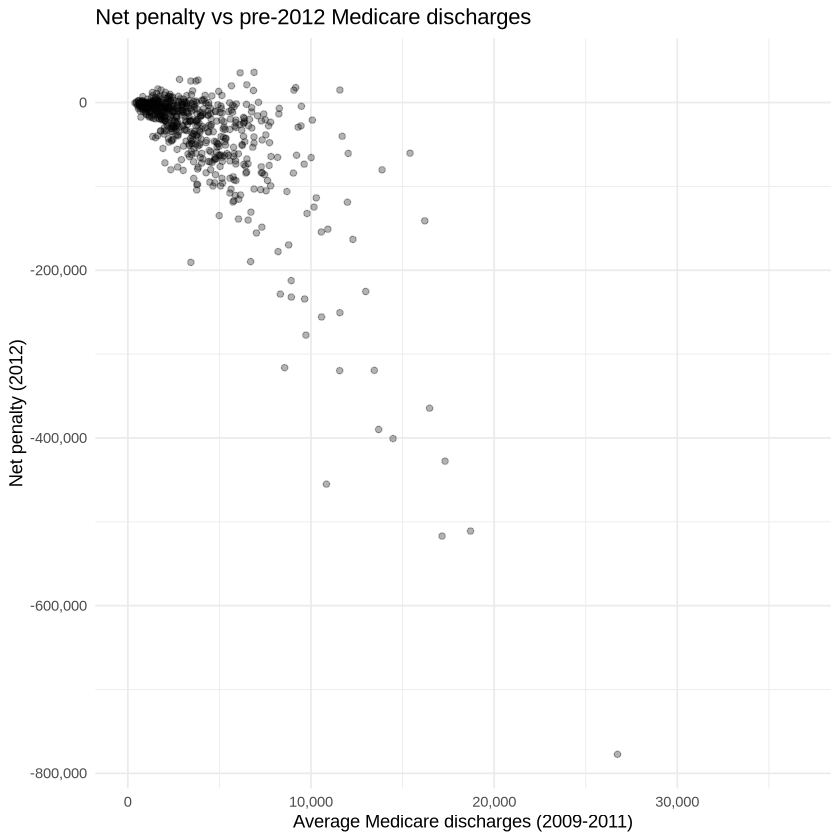

In [9]:
ggplot(hcris.final, aes(x = avg_mcare, y = net_penalty)) +
  geom_point(alpha = 0.3) +
  scale_x_continuous(labels = scales::comma) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Net penalty vs pre-2012 Medicare discharges",
    x = "Average Medicare discharges (2009-2011)",
    y = "Net penalty (2012)"
  ) +
  theme_minimal()

## Problem 8

In [10]:
library(fixest)

# First stage: net_penalty ~ avg_mcare (instrument)
fs1 <- feols(net_penalty ~ avg_mcare, data = hcris.final)
fs2 <- feols(net_penalty ~ avg_mcare + avg_beds, data = hcris.final)
fs3 <- feols(net_penalty ~ avg_mcare + avg_beds + avg_mcaid, data = hcris.final)

# Reduced form: price_change ~ avg_mcare (instrument)
rf1 <- feols(price_change ~ avg_mcare, data = hcris.final)
rf2 <- feols(price_change ~ avg_mcare + avg_beds, data = hcris.final)
rf3 <- feols(price_change ~ avg_mcare + avg_beds + avg_mcaid, data = hcris.final)

cat("=== First Stage ===\n")
summary(fs1)
summary(fs2)
summary(fs3)

cat("=== Reduced Form ===\n")
summary(rf1)
summary(rf2)
summary(rf3)

NOTE: 1,892 observations removed because of NA values (LHS: 1,892).

NOTE: 1,892 observations removed because of NA values (LHS: 1,892).

NOTE: 1,892 observations removed because of NA values (LHS: 1,892, RHS: 10).

NOTE: 10 observations removed because of NA values (RHS: 10).



=== First Stage ===


OLS estimation, Dep. Var.: net_penalty
Observations: 609 
Standard-errors: IID 
             Estimate  Std. Error   t value  Pr(>|t|)    
(Intercept) 29743.201 3156.380225   9.42320 < 2.2e-16 ***
avg_mcare     -17.423    0.639525 -27.24375 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 47,740.5   Adj. R2: 0.54937

OLS estimation, Dep. Var.: net_penalty
Observations: 609 
Standard-errors: IID 
                Estimate  Std. Error    t value  Pr(>|t|)    
(Intercept) 29685.134168 3159.805483   9.394608 < 2.2e-16 ***
avg_mcare     -17.440836    0.640651 -27.223621 < 2.2e-16 ***
avg_beds        0.356921    0.629442   0.567044   0.57089    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 47,727.9   Adj. R2: 0.548866

OLS estimation, Dep. Var.: net_penalty
Observations: 609 
Standard-errors: IID 
               Estimate  Std. Error    t value  Pr(>|t|)    
(Intercept) 29232.42164 3190.264497   9.163009 < 2.2e-16 ***
avg_mcare     -17.77539    0.718693 -24.732929 < 2.2e-16 ***
avg_beds        0.35052    0.629444   0.556873   0.57782    
avg_mcaid       1.14919    1.118989   1.026989   0.30484    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 47,686.3   Adj. R2: 0.548906

=== Reduced Form ===


OLS estimation, Dep. Var.: price_change
Observations: 2,501 
Standard-errors: IID 
              Estimate Std. Error  t value  Pr(>|t|)    
(Intercept) 195.276912  71.919040 2.715232 0.0066685 ** 
avg_mcare     0.014679   0.015039 0.976096 0.3291113    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,352.9   Adj. R2: -1.889e-5

OLS estimation, Dep. Var.: price_change
Observations: 2,501 
Standard-errors: IID 
              Estimate Std. Error  t value  Pr(>|t|)    
(Intercept) 190.618903  71.885690 2.651695 0.0080595 ** 
avg_mcare     0.011017   0.015110 0.729153 0.4659762    
avg_beds      0.070904   0.030794 2.302547 0.0213862 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,350.4   Adj. R2: 0.0017

OLS estimation, Dep. Var.: price_change
Observations: 2,491 
Standard-errors: IID 
              Estimate Std. Error  t value   Pr(>|t|)    
(Intercept) 145.659204  72.808167  2.00059 4.5545e-02 *  
avg_mcare    -0.021917   0.017315 -1.26573 2.0573e-01    
avg_beds      0.067538   0.030768  2.19507 2.8251e-02 *  
avg_mcaid     0.100369   0.025474  3.94002 8.3719e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,347.0   Adj. R2: 0.007508

In [11]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)

fmt_p <- function(p) ifelse(is.na(p), NA, sprintf("%.3f", p))

get_coef <- function(model, var) {
  ct <- coef(model)
  if (var %in% names(ct)) round(ct[var], 3) else NA
}
get_p <- function(model, var) {
  pt <- coeftable(model)[, "Pr(>|t|)"]
  if (var %in% names(pt)) fmt_p(pt[var]) else NA
}

data.frame(
  Statistic = c("Intercept", "p-value", "Avg Medicare", "p-value", "Mean Beds", "p-value", "Mean Medicaid", "p-value", "# Obs", "R2"),
  `FS 1` = c(get_coef(fs1, "(Intercept)"), get_p(fs1, "(Intercept)"), get_coef(fs1, "avg_mcare"), get_p(fs1, "avg_mcare"), NA, NA, NA, NA, nobs(fs1), round(r2(fs1, "r2"), 3)),
  `FS 2` = c(get_coef(fs2, "(Intercept)"), get_p(fs2, "(Intercept)"), get_coef(fs2, "avg_mcare"), get_p(fs2, "avg_mcare"), get_coef(fs2, "avg_beds"), get_p(fs2, "avg_beds"), NA, NA, nobs(fs2), round(r2(fs2, "r2"), 3)),
  `FS 3` = c(get_coef(fs3, "(Intercept)"), get_p(fs3, "(Intercept)"), get_coef(fs3, "avg_mcare"), get_p(fs3, "avg_mcare"), get_coef(fs3, "avg_beds"), get_p(fs3, "avg_beds"), get_coef(fs3, "avg_mcaid"), get_p(fs3, "avg_mcaid"), nobs(fs3), round(r2(fs3, "r2"), 3)),
  `RF 1` = c(get_coef(rf1, "(Intercept)"), get_p(rf1, "(Intercept)"), get_coef(rf1, "avg_mcare"), get_p(rf1, "avg_mcare"), NA, NA, NA, NA, nobs(rf1), round(r2(rf1, "r2"), 3)),
  `RF 2` = c(get_coef(rf2, "(Intercept)"), get_p(rf2, "(Intercept)"), get_coef(rf2, "avg_mcare"), get_p(rf2, "avg_mcare"), get_coef(rf2, "avg_beds"), get_p(rf2, "avg_beds"), NA, NA, nobs(rf2), round(r2(rf2, "r2"), 3)),
  `RF 3` = c(get_coef(rf3, "(Intercept)"), get_p(rf3, "(Intercept)"), get_coef(rf3, "avg_mcare"), get_p(rf3, "avg_mcare"), get_coef(rf3, "avg_beds"), get_p(rf3, "avg_beds"), get_coef(rf3, "avg_mcaid"), get_p(rf3, "avg_mcaid"), nobs(rf3), round(r2(rf3, "r2"), 3)),
  check.names = FALSE
) %>%
  kable(
    col.names = c("Statistic", "FS 1", "FS 2", "FS 3", "RF 1", "RF 2", "RF 3"),
    digits  = 3,
    booktabs = TRUE,
    caption = "First Stage and Reduced Form Results"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(c(2, 4, 6, 8), italic = TRUE, color = "gray") %>%
  add_header_above(c(" " = 1, "First Stage" = 3, "Reduced Form" = 3)) %>%
  pack_rows("Coefficients", 1, 8) %>%
  pack_rows("Model Fit", 9, 10)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>First Stage and Reduced Form Results</caption>
 <thead>
<tr>
<th style="empty-cells: hide;border-bottom:hidden;" colspan="1"></th>
<th style="border-bottom:hidden;padding-bottom:0; padding-left:3px;padding-right:3px;text-align: center; " colspan="3"><div style="border-bottom: 1px solid #ddd; padding-bottom: 5px; ">First Stage</div></th>
<th style="border-bottom:hidden;padding-bottom:0; padding-left:3px;padding-right:3px;text-align: center; " colspan="3"><div style="border-bottom: 1px solid #ddd; padding-bottom: 5px; ">Reduced Form</div></th>
</tr>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Statistic </th>
   <th style="text-align:left;font-weight: bold;"> FS 1 </th>
   <th style="text-align:left;font-weight: bold;"> FS 2 </th>
   <th style="text-align:left;font-weight: bold;"> FS 3 </th>
   <th style="text-align:left;font-weight: bold;"> RF 1 </th>
   <th style="text-align:left;font-weight: bol

## Problem 9

In [12]:
# IV estimates: price_change ~ net_penalty, instrumented by avg_mcare
iv1 <- feols(price_change ~ 1 | net_penalty ~ avg_mcare, data = hcris.final)
iv2 <- feols(price_change ~ avg_beds | net_penalty ~ avg_mcare, data = hcris.final)
iv3 <- feols(price_change ~ avg_beds + avg_mcaid | net_penalty ~ avg_mcare, data = hcris.final)

summary(iv1)
summary(iv2)
summary(iv3)

NOTE: 1,892 observations removed because of NA values (IV: 1,892/0).

NOTE: 1,892 observations removed because of NA values (IV: 1,892/0).

NOTE: 1,892 observations removed because of NA values (RHS: 10, IV: 1,892/0).



TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: avg_mcare
Second stage: Dep. Var.: price_change
Observations: 609 
Standard-errors: IID 
                  Estimate Std. Error  t value   Pr(>|t|)    
(Intercept)     345.139140 103.865386  3.32295 0.00094428 ***
fit_net_penalty  -0.003071   0.001595 -1.92579 0.05459777 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,074.3   Adj. R2: 8.94e-4
F-test (1st stage), net_penalty: stat = 742.2    , p < 2.2e-16 , on 1 and 607 DoF.
                     Wu-Hausman: stat =   1.22746, p = 0.268341, on 1 and 606 DoF.

TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: avg_mcare
Second stage: Dep. Var.: price_change
Observations: 609 
Standard-errors: IID 
                  Estimate Std. Error  t value  Pr(>|t|)    
(Intercept)     329.076332 103.743457  3.17202 0.0015904 ** 
fit_net_penalty  -0.002886   0.001589 -1.81659 0.0697738 .  
avg_beds          0.064831   0.027201  2.38343 0.0174594 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,064.2   Adj. R2: 0.009019
F-test (1st stage), net_penalty: stat = 741.1    , p < 2.2e-16, on 1 and 606 DoF.
                     Wu-Hausman: stat =   0.98661, p = 0.32097, on 1 and 605 DoF.

TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: avg_mcare
Second stage: Dep. Var.: price_change
Observations: 609 
Standard-errors: IID 
                  Estimate Std. Error  t value   Pr(>|t|)    
(Intercept)     140.539969 111.041972 1.265647 2.0613e-01    
fit_net_penalty   0.000652   0.001720 0.379196 7.0468e-01    
avg_beds          0.062387   0.026764 2.330987 2.0082e-02 *  
avg_mcaid         0.211969   0.046747 4.534391 6.9666e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,028.9   Adj. R2: 0.040988
F-test (1st stage), net_penalty: stat = 611.7     , p < 2.2e-16 , on 1 and 605 DoF.
                     Wu-Hausman: stat =   0.383316, p = 0.536067, on 1 and 604 DoF.

In [13]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)

fmt_p <- function(p) ifelse(is.na(p), NA, sprintf("%.3f", p))

get_coef <- function(model, var) {
  ct <- coef(model)
  if (var %in% names(ct)) round(ct[var], 3) else NA
}
get_p <- function(model, var) {
  pt <- coeftable(model)[, "Pr(>|t|)"]
  if (var %in% names(pt)) fmt_p(pt[var]) else NA
}

data.frame(
  Statistic = c("Intercept", "p-value", "Net Penalty", "p-value", "Mean Beds", "p-value", "Mean Medicaid", "p-value", "# Obs", "R2"),
  `IV 1` = c(get_coef(iv1, "(Intercept)"), get_p(iv1, "(Intercept)"), get_coef(iv1, "fit_net_penalty"), get_p(iv1, "fit_net_penalty"), NA, NA, NA, NA, nobs(iv1), round(r2(iv1, "r2"), 3)),
  `IV 2` = c(get_coef(iv2, "(Intercept)"), get_p(iv2, "(Intercept)"), get_coef(iv2, "fit_net_penalty"), get_p(iv2, "fit_net_penalty"), get_coef(iv2, "avg_beds"), get_p(iv2, "avg_beds"), NA, NA, nobs(iv2), round(r2(iv2, "r2"), 3)),
  `IV 3` = c(get_coef(iv3, "(Intercept)"), get_p(iv3, "(Intercept)"), get_coef(iv3, "fit_net_penalty"), get_p(iv3, "fit_net_penalty"), get_coef(iv3, "avg_beds"), get_p(iv3, "avg_beds"), get_coef(iv3, "avg_mcaid"), get_p(iv3, "avg_mcaid"), nobs(iv3), round(r2(iv3, "r2"), 3)),
  check.names = FALSE
) %>%
  kable(
    col.names = c("Statistic", "IV 1", "IV 2", "IV 3"),
    digits  = 3,
    booktabs = TRUE,
    caption = "IV Results of Penalty Status on Price Change"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(c(2, 4, 6, 8), italic = TRUE, color = "gray") %>%
  pack_rows("Coefficients", 1, 8) %>%
  pack_rows("Model Fit", 9, 10)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>IV Results of Penalty Status on Price Change</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Statistic </th>
   <th style="text-align:left;font-weight: bold;"> IV 1 </th>
   <th style="text-align:left;font-weight: bold;"> IV 2 </th>
   <th style="text-align:left;font-weight: bold;"> IV 3 </th>
  </tr>
 </thead>
<tbody>
  <tr grouplength="8"><td colspan="4" style="border-bottom: 1px solid;"><strong>Coefficients</strong></td></tr>
<tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Intercept </td>
   <td style="text-align:left;"> 345.139 </td>
   <td style="text-align:left;"> 329.076 </td>
   <td style="text-align:left;"> 140.54 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;font-style: italic;color: gray !important;padding-left: 2em;" indentlevel="1"> p-value </td>
   <td style="text-align:left;font-style: italic;color: gr

## Problem 10

Briefly explain the “Local” ATE in the context of your estimates. How might a local effect differ from an overall ATE in this setting?

Local ATE would be the average treatment effect that are only for hospitals that were penalized because of their Medicare share. This would capture the effect of penalty status on price changes only for hospitals that were penalized from Medicare patient share, making it a narrower group than all penalized hospitals. The local effect could be larger than ATE if the hospitals within the local group is more sensitive to Medicare reimbursement changes. 